Lex Albrandt  
CS440  
HW 2 writeup  

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

## Question 1
Note: All hyperparameters are indicated in the  
title of each figure for this section 

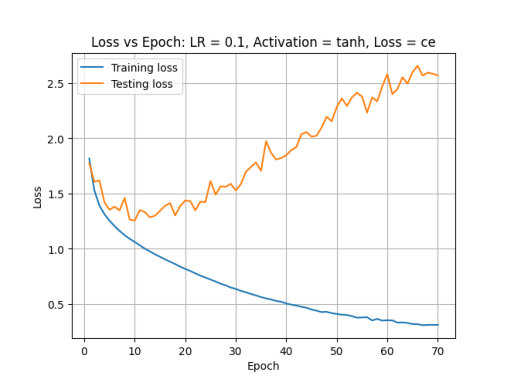

In [3]:
img = mpimg.imread("Figure_1_test1.png")
plt.axis("off")
plt.imshow(img)
plt.show()

In this test we see that the training loss converges  
to a low value, indicating that it has learned the  
training data very well. We see, however, that the testing  
loss initially decreases with the training loss, but diverges  
and continues to increse. This indicates that the model has  
begun to overfit the training parameters and is no longer able  
to generalize, subsequently causing the model to perform poorly  
on unseen data. Because the learning rate in this test is quite high  
the gradient steps between epochs make much larger adjustments, which  
can cause the model to memorize the data, and lose the ability to  
generalize.

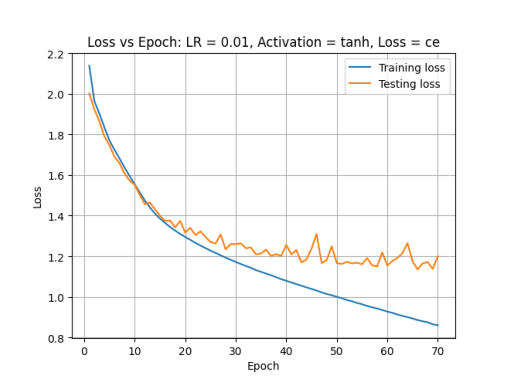

In [4]:
img = mpimg.imread("Figure_1_test2.png")
plt.axis("off")
plt.imshow(img)
plt.show()

In this test, we see that the model does a much better job of  
learning patterns present in both the training and test data,  
however, after about 20 epochs, the model clearly begins to overfit the  
data, learning patterns like noise that do not exist in the test set.  

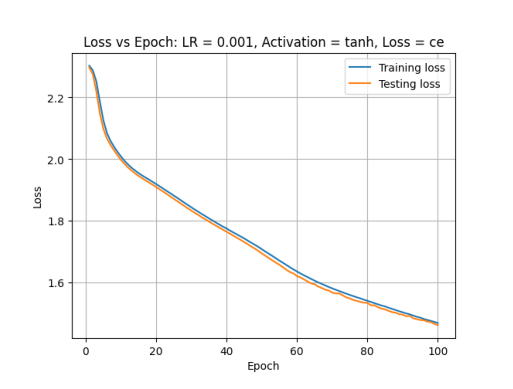

In [5]:
img = mpimg.imread("Figure_1_test3.png")
plt.axis("off")
plt.imshow(img)
plt.show()

Here we see that the model training loss and testing loss are closely  
matched, indicating that the model is generalizing well, and applying  
learned patterns to unseen data, rather than memorizing the training set.   
The lower learning rate contributes to the model's stability, which  
prevents large shifts in the weights between epochs, and mitigates  
overfitting.  

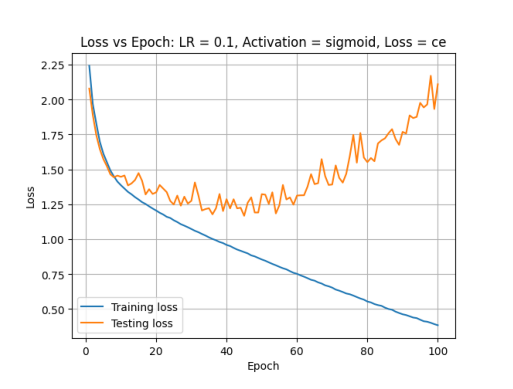

In [6]:
img = mpimg.imread("Figure_1_test4.png")
plt.axis("off")
plt.imshow(img)
plt.show()

Once again, in this test we see that the learning rate causes an  
overfitting of the data and loss of generalization, despite a  
different activation function.

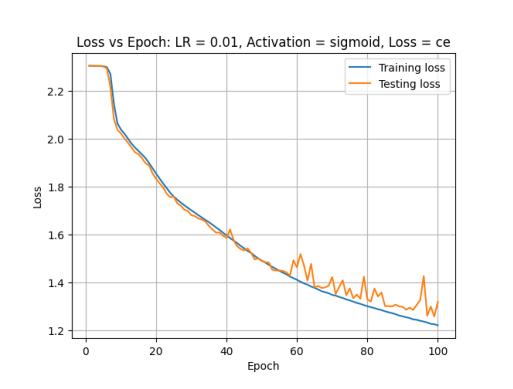

In [7]:
img = mpimg.imread("Figure_1_test5.png")
plt.axis("off")
plt.imshow(img)
plt.show()

In this test we see that the training and test losses remain closely  
matched, but diverge after around 60 epochs, again indicating overfitting.

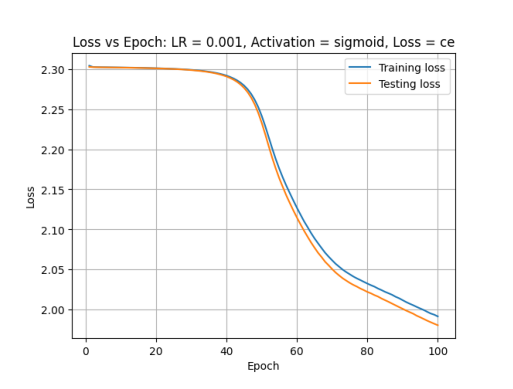

In [8]:
img = mpimg.imread("Figure_1_test6.png")
plt.axis("off")
plt.imshow(img)
plt.show()

In ths test we again see closely matched training and test loss,  
and a pattern has started to emerge regarding performance: it appears  
that the most important determining factor for good generalization with  
this data and this model is a low learning rate of 0.001

For the sake of space I will show the next few test plots, as they  
follow a similar pattern to the plots shown above  

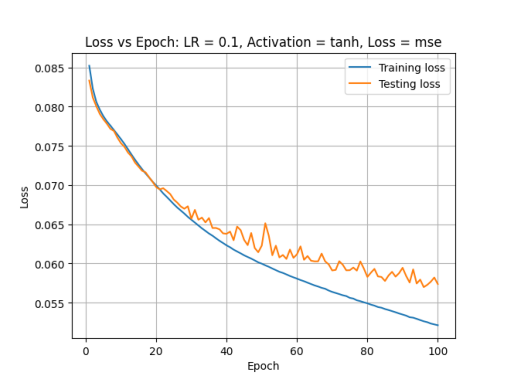

In [9]:
img = mpimg.imread("Figure_1_test7.png")
plt.axis("off")
plt.imshow(img)
plt.show()

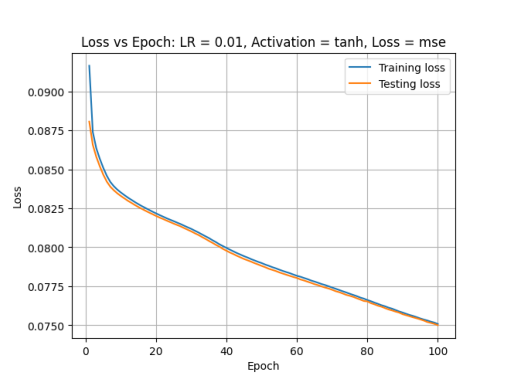

In [10]:
img = mpimg.imread("Figure_1_test8.png")
plt.axis("off")
plt.imshow(img)
plt.show()

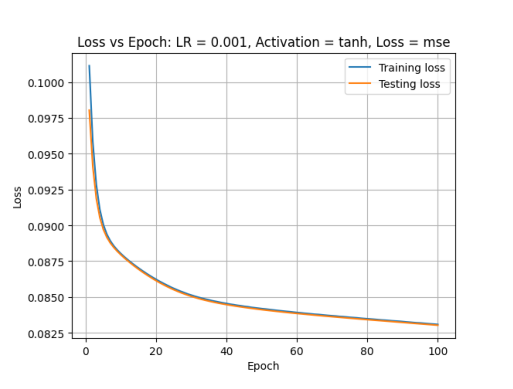

In [11]:
img = mpimg.imread("Figure_1_test9.png")
plt.axis("off")
plt.imshow(img)
plt.show()

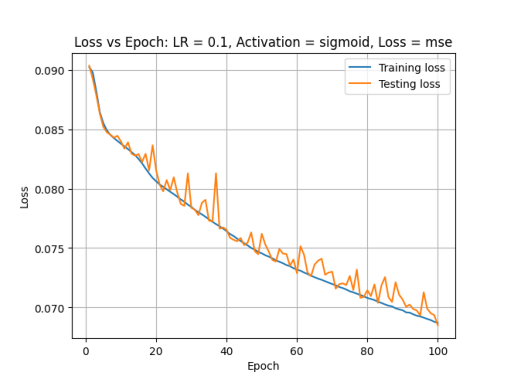

In [12]:
img = mpimg.imread("Figure_1_test10.png")
plt.axis("off")
plt.imshow(img)
plt.show()

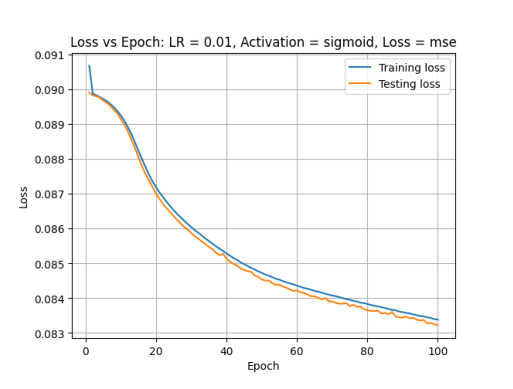

In [13]:
img = mpimg.imread("Figure_1_test11.png")
plt.axis("off")
plt.imshow(img)
plt.show()

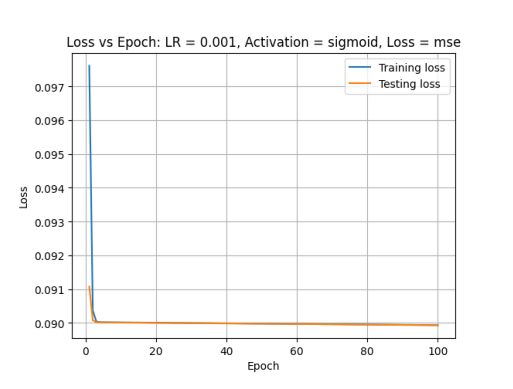

In [14]:
img = mpimg.imread("Figure_1_test12.png")
plt.axis("off")
plt.imshow(img)
plt.show()

We can see, generally, that a lower learning rate increases the stability  
of the model, and allows it to generalize effectively. 

# Feature Maps for Test 9  
Below are three of the feature maps for test #9 which had the following hyperparamaters:  
- Learning Rate: 0.001  
- Activation Function: Tanh
- Loss Function: MSE  
  

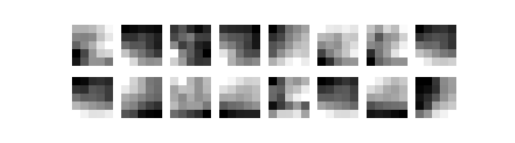

In [15]:
img = mpimg.imread("fm_1.png")
plt.axis("off")
plt.imshow(img)
plt.show()

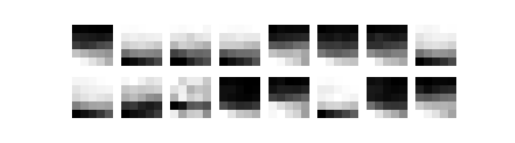

In [16]:
img = mpimg.imread("fm_2.png")
plt.axis("off")
plt.imshow(img)
plt.show()

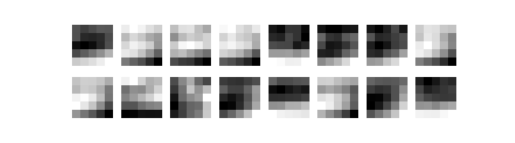

In [17]:
img = mpimg.imread("fm_3.png")
plt.axis("off")
plt.imshow(img)
plt.show()

In the above feature maps we see that the feature maps at the last  
layer of convolution are abstract and generalized, indicating that the  
model is learning abstract lines or shapes to categorize images. The  
further we go into the model the more abstract these maps become, as we  
see in the maps above.

## Question 2
   
Kernel size:  
- 3x3   
  
Hyperparameters for this test:  
- Learning Rate: 0.001  
- Activation Function: ReLU  
- Loss Function: Cross Entropy  

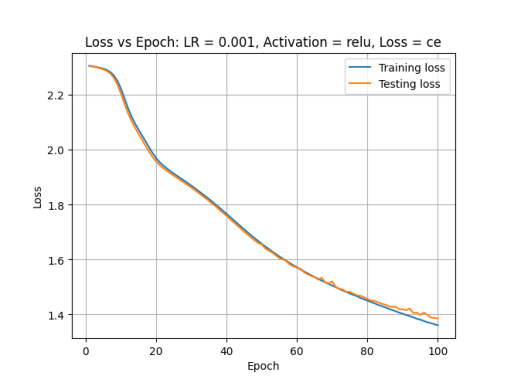

In [18]:
img = mpimg.imread("relu_test.png")
plt.axis("off")
plt.imshow(img)
plt.show()

For this test we see a similar result to other tests that have a low learning  
rate: the model is generalizing well, and categorizing unseen data appropriately  
Because we are using the ReLU activation only neurons with positive output are "active"  
which reduces noise in the network, which in turn helps avoid overfitting and memorization  
and also improves generalization, which allows the model to perform better on unseen  
data.   
  

## Question 3
  
### Stock Market Predictions  
  
The task for this section was to create a RNN to predict the stock market prices for  
the 101st value after seeing 100 values of high prices from the Dow Jones data set.  
I chose to use an LSTM RNN for this section because it is good at capturing trends  
and cycles in stock prices. A typical RNN could also be used, but to my understanding  
would suffer from vanishing gradients, which would be a problem for long periods of time  
series data. 

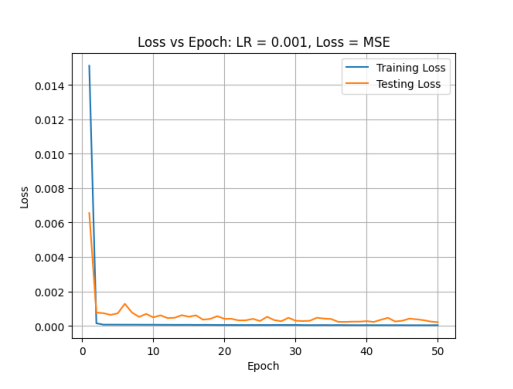

In [19]:
img = mpimg.imread("rnn_stocks.png")
plt.axis("off")
plt.imshow(img)
plt.show()

We see above that the training loss decreases rapidly and approaches zero, which  
indicates that the model is closely fit to the training data. It's also worth noting  
that the testing loss is also low, and the model is generalizing fairly well. The  
testing loss remains low because predicting a stock value from the day before is highly  
autocorrelated, meaning the flucuation in value from day to day is miniscule, so the model  
does a good job of predicting values from day to day.  
  
This is very different from predicting sin(x) because sin(x) is, by nature, periodic and smooth.  
This means the model must learn the amplitude and phase of the function to predict next values  
correctly, and must learn the pattern of the full function over time.  
Because stocks have minute shifts day to day, short-term prediction is much easier.  
  
### Weather Data for Seattle  
   
#### Discrete Fourier Transform  
  

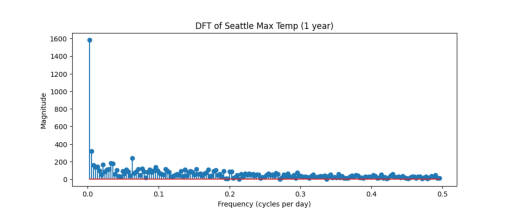

In [20]:
df = pd.read_csv("seattle-weather.csv")

# Extract one year and three years of data
one_year_data = df["temp_max"].values[10:375]

# Perform DFT
fft_vals = np.fft.fft(one_year_data)
fft_freqs = np.fft.fftfreq(len(one_year_data), d = 1)

# Compute magnitude spectrum
magnitude = np.abs(fft_vals)

skip = 1

# Plot data
plt.figure(figsize = (10, 4))
plt.stem(fft_freqs[skip:len(fft_freqs) // 2], magnitude[skip:len(magnitude) // 2])
plt.xlabel("Frequency (cycles per day)")
plt.ylabel('Magnitude')
plt.title("DFT of Seattle Max Temp (1 year)")
plt.show()

fft_list = list(zip(fft_freqs, magnitude))
fft_list_sorted = sorted(fft_list, key = lambda x: x[1], reverse = True)
for f, mag in fft_list_sorted[:10]:
    period_days = 1 / f if f != 0 else np.inf
    print(f"Frequency: {f:.4f} cycles/day, Magnitude: {mag:.2f}, period: {period_days:.1f} days")

We can see on the DFT plot for one year of weather data there is a large frequency spike at  
around $0.002 \text{ cycles/day}$. To determine the period we use the formula:  
$\text{Period}=\frac{1}{frequency}=\frac{1}{0.002}\approx 365\text{ days}$  
This makes sense for weather cycles, given that the trends are often cyclical around the year.  
We also see spikes at 180 days, and 30 days, which again, makes sense given the cyclical nature  
of weather patterns.

In [ ]:
df = pd.read_csv("seattle-weather.csv")

# Extract one year and three years of data
three_year_data = df["temp_max"].values[:1095]

# Perform DFT
fft_vals = np.fft.fft(three_year_data)
fft_freqs = np.fft.fftfreq(len(three_year_data), d = 1)

# Compute magnitude spectrum
magnitude = np.abs(fft_vals)

skip = 1

# Plot data
plt.figure(figsize = (10, 4))
plt.stem(fft_freqs[skip:len(fft_freqs) // 2], magnitude[skip:len(magnitude) // 2])
plt.xlabel("Frequency (cycles per day)")
plt.ylabel('Magnitude')
plt.title("DFT of Seattle Max Temp (1 year)")
plt.show()

fft_list = list(zip(fft_freqs, magnitude))
fft_list_sorted = sorted(fft_list, key = lambda x: x[1], reverse = True)
for f, mag in fft_list_sorted[:10]:
    period_days = 1 / f if f != 0 else np.inf
    print(f"Frequency: {f:.4f} cycles/day, Magnitude: {mag:.2f}, period: {period_days:.1f} days")

As with the one year data, we see spikes around 365 days, 180 days, and 30 days  
which makes sense given yearly and semi-yearly cycles of weather change.  
  
#### 3-year Weather prediction  
  
For this section of the assignment I used a very similar architecture to the stock  
value prediction model, with the key difference of using a sliding-window  
approach with a look-back window of 10 dyas to predict the temperature for  
the next day. I used MSE and the Adam optimizer. I fed the true temperature values  
from the test set back into the sliding window at each timestep.

In [ ]:
img = mpimg.imread("temp.png")
plt.axis("off")
plt.imshow(img)
plt.show()

We observce that the predicted temperatures closely track the overall trend of actual  
temperatures. It is apparent that the trends appear smoother with less day-to-day variability.  
This is because the model was trained to minimize MSE over overlapping sliding windows, which  
causes the model to dampen the sharp fluctuations we see in the actual temperatures. We see  
that the model has generalized well, and has mitigated the tradeoffs between bias and variance.  
The model tends towards a lower variance because of averaging the patterns of temperature patterns  
but also has a higher bias as seen in the rapid changes of predictions. However, the model does  
balance the bias and variance and results in overall adequate generalization.